In [10]:
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from skimage import __version__ as skimage_version

print("cv2:", cv2.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("skimage:", skimage_version)

cv2: 4.8.0
numpy: 1.24.4
matplotlib: 3.7.3
skimage: 0.21.0


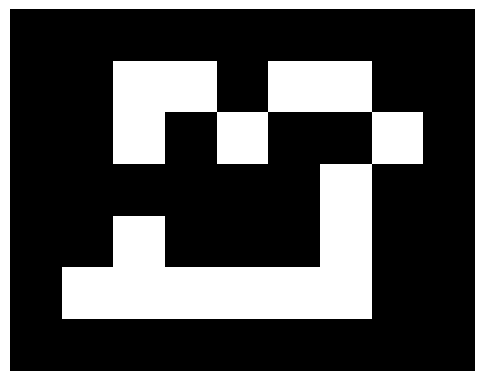

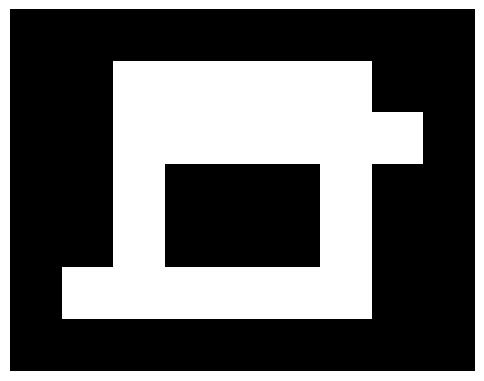

In [11]:
def read_image(path, mode='RGB'):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    mode = mode.upper()
    if mode == 'GRAYSCALE':
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    elif mode == 'RGB':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    elif mode == 'HSV':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    elif mode == 'LAB':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
    elif mode == 'CMY':
        img = 255 - cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def show_image(img, cmap=None, size=(6, 6)):
    plt.figure(figsize=size)
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

def true_grayscale_normalize(img):
    gray = convert_color(img, 'GRAYSCALE')
    return gray.astype(np.float32) / 255

def convert_color(img, mode='RGB'):
    mode = mode.upper()
    if mode == 'GRAYSCALE':
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if mode == 'HSV':
        return cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    if mode == 'LAB':
        return cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    if mode == 'CMY':
        return 255 - img
    return img

before = true_grayscale_normalize(read_image('data/source.png'))
after = true_grayscale_normalize(read_image('data/destination.png'))

show_image(before)
show_image(after)

Let A be the binary input image, and B be the structuring element (SE).

- Erosion (A ⊖ B): Shrinks white regions. Only keeps pixels where SE B fits entirely within A.
- Dilation (A ⊕ B): Expands white regions. Adds pixels to boundaries where SE B touches any foreground pixel in A.
- Opening (A ○ B): Opening is erosion followed by dilation. Smooths contour, removes small foreground noise, preserves background:

> A ○ B = (A ⊖ B) ⊕ B

- Closing (A ● B): Closing is dilation followed by erosion. Fills small holes/gaps in foreground regions, preserves foreground:

> A ● B = (A ⊕ B) ⊖ B

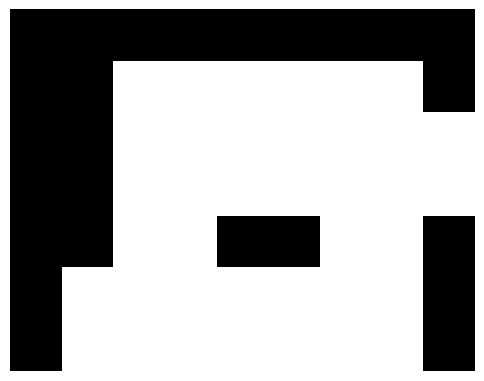

In [12]:
from scipy.ndimage import binary_erosion, binary_dilation, binary_opening, binary_closing

def erode(img, se=np.ones((3,3)), iterations=1):
    return binary_erosion(img, structure=se, iterations=iterations).astype(np.uint8)

def dilate(img, se=np.ones((3,3)), iterations=1):
    return binary_dilation(img, structure=se, iterations=iterations).astype(np.uint8)

def open_img(img, se=np.ones((3,3)), iterations=1):
    return binary_opening(img, structure=se, iterations=iterations).astype(np.uint8)

def close_img(img, se=np.ones((3,3)), iterations=1):
    return binary_closing(img, structure=se, iterations=iterations).astype(np.uint8)

se1 = np.array([[0,0,0],[0,1,1],[0,1,1]])

processed1 = dilate(before, se1)
show_image(processed1)

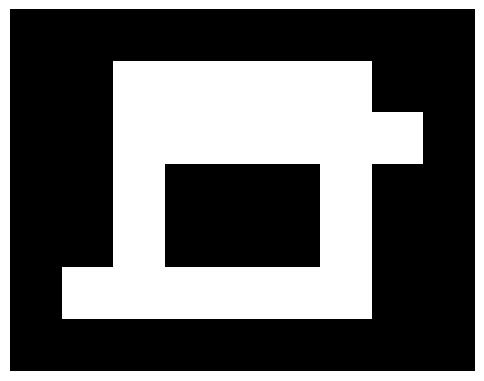

In [26]:
se2 = np.array([[0,0,0],[0,1,1],[0,1,1]])
processed2 = erode(processed1, se1)
show_image(processed2)

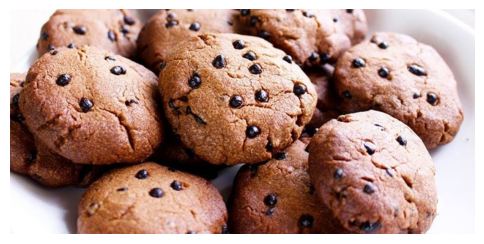

In [14]:
cookie = read_image('data/original.jpg')
show_image(cookie)

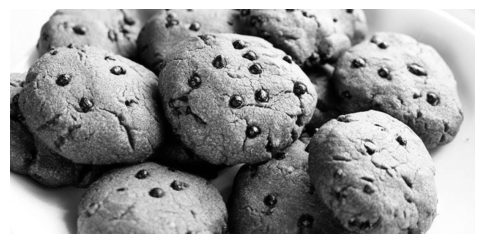

In [15]:
cookie_gray = convert_color(cookie, 'GRAYSCALE')
show_image(cookie_gray)

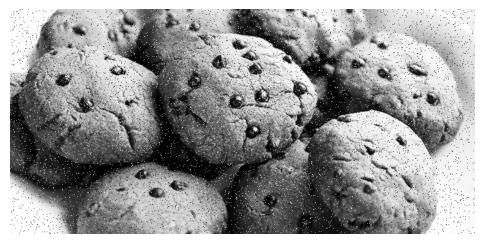

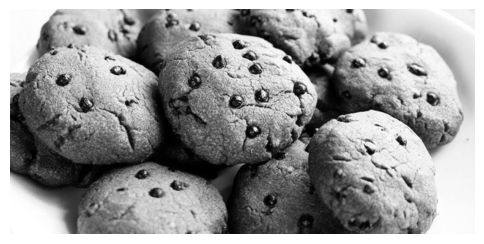

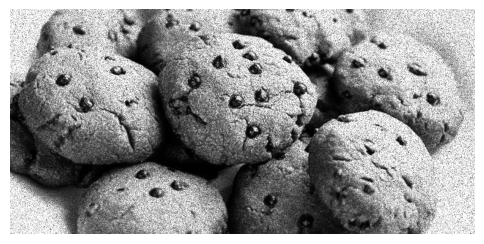

In [16]:
def add_gaussian_noise(img, mean=0, std=10):
    noise = np.random.normal(mean, std, img.shape)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(img, amount=0.01, salt_vs_pepper=0.5):
    noisy = img.copy()
    total = np.prod(img.shape[:2])
    num_salt = int(amount * total * salt_vs_pepper)
    num_pepper = int(amount * total * (1 - salt_vs_pepper))

    coords = tuple(np.random.randint(0, i, num_salt) for i in img.shape[:2])
    if len(img.shape) == 2:
        noisy[coords] = 255
    else:
        noisy[coords[0], coords[1], :] = 255

    coords = tuple(np.random.randint(0, i, num_pepper) for i in img.shape[:2])
    if len(img.shape) == 2:
        noisy[coords] = 0
    else:
        noisy[coords[0], coords[1], :] = 0

    return noisy

def add_speckle_noise(img, strength=0.1):
    noise = np.random.randn(*img.shape)
    noisy = img.astype(np.float32) + img.astype(np.float32) * noise * strength
    return np.clip(noisy, 0, 255).astype(np.uint8)

sp_cookie = add_salt_pepper_noise(cookie_gray, 0.05)
gaussian_cookie = add_gaussian_noise(cookie_gray, 0, 0.25)
speckle_cookie = add_speckle_noise(cookie_gray, 0.25)

show_image(sp_cookie)
show_image(gaussian_cookie)
show_image(speckle_cookie)

In [17]:
from scipy.ndimage import gaussian_filter, median_filter, uniform_filter, generic_filter
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import warnings

def gaussian_blur(img, size=3, strength=1.0, sigma=1.0, pad=0, stride=1):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if pad > 0:
        img = np.pad(img, pad, mode='constant')
    blurred = gaussian_filter(img, sigma=sigma * strength)
    if stride > 1:
        blurred = blurred[::stride, ::stride]
    return np.clip(blurred, 0, 255).astype(np.uint8)

def median_blur(img, size=3, strength=1.0, pad=0, stride=1):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if pad > 0:
        img = np.pad(img, pad, mode='constant')
    final_size = max(1, int(size * strength) | 1)
    filtered = median_filter(img, size=final_size)
    if stride > 1:
        filtered = filtered[::stride, ::stride]
    return np.clip(filtered, 0, 255).astype(np.uint8)

def mean_blur(img, size=3, strength=1.0, pad=0, stride=1):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if pad > 0:
        img = np.pad(img, pad, mode='constant')
    final_size = max(1, int(size * strength) | 1)
    blurred = uniform_filter(img, size=final_size)
    if stride > 1:
        blurred = blurred[::stride, ::stride]
    return np.clip(blurred, 0, 255).astype(np.uint8)

def compute_ssim(img1, img2):
    if img1.shape != img2.shape:
        warnings.warn("Images have different shapes.")
        return None
    if len(img1.shape) == 2:
        return structural_similarity(img1, img2, data_range=img1.max() - img1.min())
    return structural_similarity(img1, img2, multichannel=True, data_range=img1.max() - img1.min())

### Salt & Pepper Noise

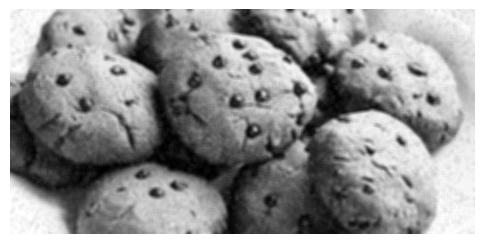

0.5921172006707901


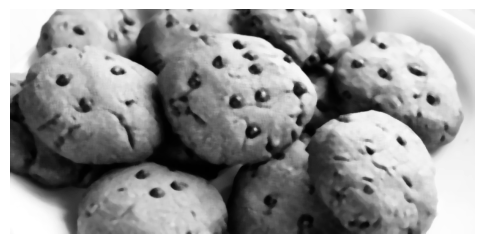

0.6896109833670478


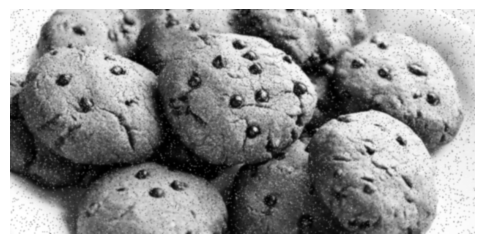

0.70965112291306


In [18]:
mean_sp = mean_blur(sp_cookie, 7, 1.0)
median_sp = median_blur(sp_cookie, 7, 1.0)
gaussian_sp = gaussian_blur(sp_cookie, 7, 1.0, 1.0)

show_image(mean_sp)
print(compute_ssim(mean_sp, cookie_gray))
show_image(median_sp)
print(compute_ssim(median_sp, cookie_gray))
show_image(gaussian_sp)
print(compute_ssim(gaussian_sp, cookie_gray))

- Median filter works best for S&P noise.

### Gaussian Noise

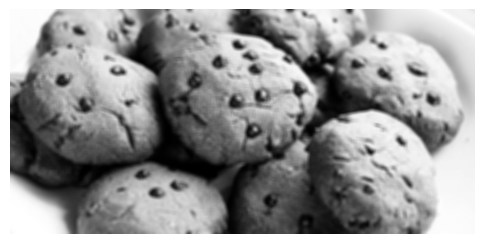

0.6515799721606771


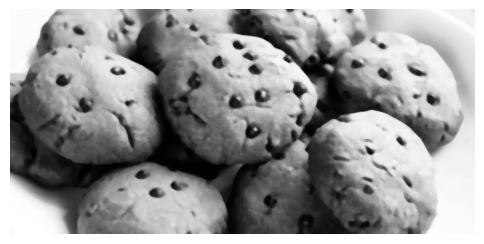

0.6904642229583593


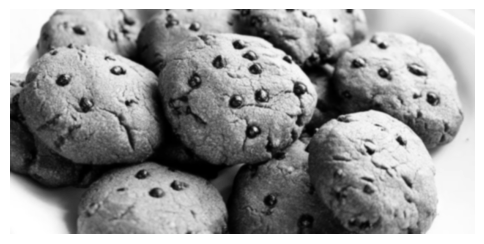

0.8996688896553009


In [19]:
mean_gauss = mean_blur(gaussian_cookie, 7, 1.0)
median_gauss = median_blur(gaussian_cookie, 7, 1.0)
gaussian_gauss = gaussian_blur(gaussian_cookie, 7, 1.0, 1.0)

show_image(mean_gauss)
print(compute_ssim(mean_gauss, cookie_gray))
show_image(median_gauss)
print(compute_ssim(median_gauss, cookie_gray))
show_image(gaussian_gauss)
print(compute_ssim(gaussian_gauss, cookie_gray))

- The Gaussian Noise here is relatively weak so it's easy to denoise, mean and median blurs more than gaussian filter.

### Speckle Noise

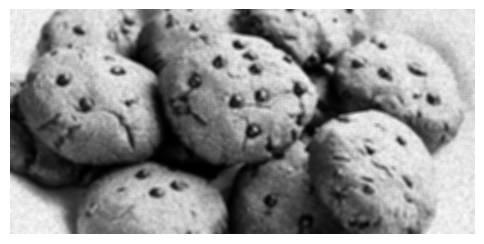

0.5924452865236558


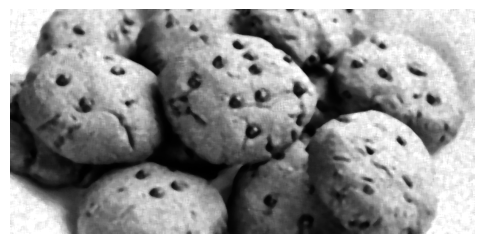

0.5886211681095678


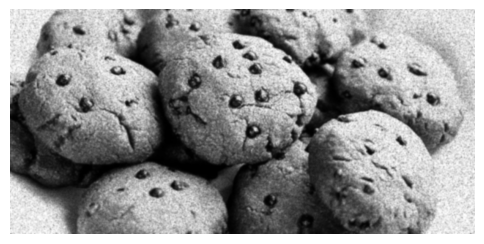

0.7091721057036573


In [20]:
mean_speckle = mean_blur(speckle_cookie, 7, 1.0)
median_speckle = median_blur(speckle_cookie, 7, 1.0)
gaussian_speckle = gaussian_blur(speckle_cookie, 7, 1.0, 1.0)

show_image(mean_speckle)
print(compute_ssim(mean_speckle, cookie_gray))
show_image(median_speckle)
print(compute_ssim(median_speckle, cookie_gray))
show_image(gaussian_speckle)
print(compute_ssim(gaussian_speckle, cookie_gray))

- Speckle Noise is very difficult to remove due to multiplacation in the noise model:

$$
I_{\text{speckle}} = I \cdot (1 + N)
$$

- Where $ N $ is normally distributed.
- Gaussian filter blurs the least here.

> Note: SSIM is not always aligned with human's vision perception

In [21]:
def edge_detection_range_3x3(img):
    gray = img
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    height, width = blur.shape
    edge_img = np.zeros_like(blur)

    for y in range(1, height - 1):
        for x in range(1, width - 1):
            block_3x3 = blur[y-1:y+2, x-1:x+2]
            min_val = np.min(block_3x3)
            max_val = np.max(block_3x3)
            range_val = max_val - min_val
            edge_img[y, x] = range_val
            
    return edge_img

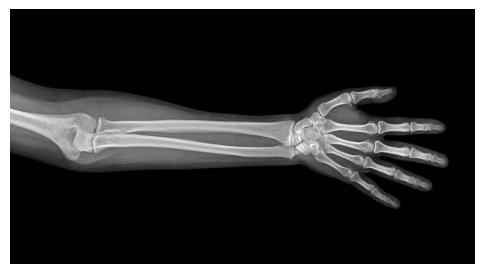

In [22]:
skeleton = true_grayscale_normalize(read_image('data/xray.jpg'))
show_image(skeleton)

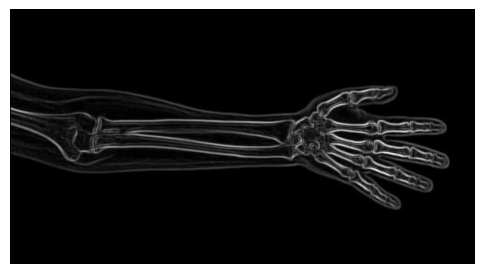

In [23]:
processed_xray = edge_detection_range_3x3(skeleton)
show_image(processed_xray)

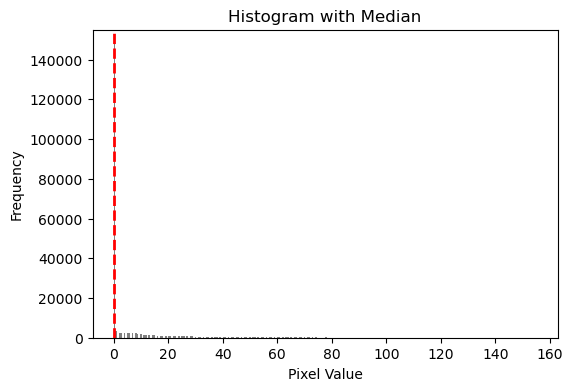

0.0


In [24]:
def show_histogram_with_median(img):
    plt.figure(figsize=(6, 4))
    values = img.ravel()
    plt.hist(values, bins=256, range=(values.min(), values.max()), color='gray')
    median = np.median(values)
    plt.axvline(median, color='red', linestyle='--', linewidth=2)
    plt.title('Histogram with Median')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.show()
    return median

def denormalize(img):
    return np.clip(img * 255, 0, 255).astype(np.uint8)

processed_xray_denom = denormalize(processed_xray)

median = show_histogram_with_median(processed_xray_denom)
print(median)

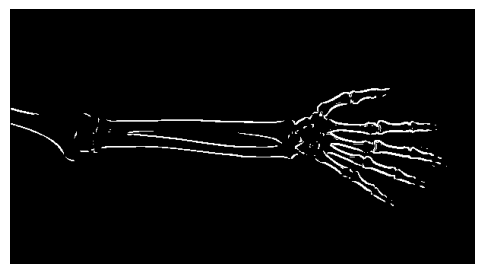

In [25]:
def threshold(img, value):
    return (img > value).astype(np.uint8)

binary_xray = threshold(processed_xray_denom, 55)
show_image(binary_xray)

#### I don't think there's need for morphological filters here